## NB5 — Gene Program Negotiation (GPN) on cNMF Usage Programs

**Pipeline:** NB1 (GSEA cell-type scoring) → NB2 (`per_gep_labels.tsv`, GEP tree) → NB4 (ROGUE purity audit) → NB5 (this notebook).

**Source:** Sung & Cheong, *Gene Program Negotiation Defines Cellular Identity in Single-Cell Transcriptomes*, bioRxiv 2026 (doi: 10.64898/2026.07.05.736629).

**Reframing for this pipeline:** GPN was built around independently-scored Hallmark gene programs (stemness, EMT, hypoxia, ...). This pipeline already has a richer, purpose-built multi-program decomposition: the **cNMF usage matrix** — every cell's continuous, non-negative activity across all GEPs at a given K. That *is* GPN's "program activity matrix." So instead of re-deriving program scores, this notebook runs GPN's graph math directly on cNMF's own usage output, at every K NB1/NB2/NB4 already scored, and validates the resulting regulatory states against artifacts those notebooks already produced — rather than the paper's own pseudotime-based validation, which scores "transition-like cells" from the same conflict/diversity/GPCI values it then validates against. NB4's ROGUE purity is a fully independent instability proxy, so it stands in for that step here.

**What's adapted from the paper, and why:**
- **Programs = GEPs**, not Hallmark sets. `*.usages.k_{K}.dt_0_01.consensus.txt` (cells × GEPs) is the activity matrix for every K.
- **Neighborhood graph = kNN on Harmony space** (`adata.obsm['X_harmony']`), not raw PCA. This dataset pools 63 patients (`orig.ident`); NB4 explicitly scores ROGUE *within-sample* to keep batch structure from being read as biology. The same risk applies to GPN's local-correlation neighborhoods, so we use the batch-corrected embedding and explicitly audit same-sample vs. cross-sample neighbor composition (3) instead of assuming it away.
- **"Positive program activities" is a no-op here.** cNMF usage is non-negative by construction (it's an NMF), so raw usage is used directly for activation weights / total activity / dominance / diversity. Z-scoring (which *can* go negative) is used only for the local correlation graph, exactly as the paper's Methods describe for that one step.
- **Diagonal (self-interaction) terms are excluded** from every graph sum (coherence, conflict). A program's correlation with itself is always 1 and carries no information about cross-program interaction — leaving it in would mechanically inflate coherence and deflate conflict as a pure artifact of matrix size.
- **K is swept, not fixed.** GPN metrics are computed for every K where NB1's GSEA output, NB2's `per_gep_labels.tsv`, NB1's `gep_program_class.tsv`, and NB4's ROGUE tables all exist (K = 3–35 — see 4), so every GPN state can be jointly validated against identity, identity-confidence, and purity at the same resolution.
- **Classification thresholds are the paper's starting values** (20th / 62% / 80th / 70th / 60th percentile cutoffs), shown against this dataset's own distributions in 7 before being applied in 8 — re-tune there if the diagnostic plots look off for this dataset, the same way NB1 7.2–7.3 tunes its own GSEA thresholds.
- **GEP-level negotiation profile (12).** 9–11 validate GPN entirely at the cell level (does a cell's state track its dominant-program identity, GSEA confidence, group ROGUE purity). NB6's actual decision is about a GEP/label, not a cell, so 12 re-aggregates the same per-cell outputs to the (K, GEP) grain NB6 reads directly — a `win_rate` (does this GEP's dominant population settle or stay contested?) and a `chief_rival` (which other GEP does it lose the most local negotiation weight to?) per (K, GEP), instead of another cell-level cross-tabulation.

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.neighbors import NearestNeighbors
from scipy.stats import kruskal, chi2_contingency, fisher_exact, spearmanr
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 1. Configuration

In [2]:
# Paths — same source data as NB4
ADATA_PATH = "hnc_data/hnc_myeloid_2021.h5ad"

# Same cNMF outputs as NB1 / NB2 / NB4
CNMF_DIR = "hnc_consensus_outputs_k3-35/combined_hnc_k_consensus_outputs"
CNMF_PREFIX = "combined_hnc_k"
DENSITY_THRESHOLD = "0_01"
K_MIN, K_MAX = 3, 35   # bounded by per_gep_labels.tsv / ROGUE coverage — see 4

# NB2 output — one identity label per (K, GEP)
LABELS_PATH = "hnc_combined5000hvg_clanp_results/k3-35_corr-tree_kl-divergence/per_gep_labels.tsv"

# NB1 output — one identity-confidence class per (K, GEP)
PROGRAM_CLASS_PATH = "hnc_combined5000hvg_clanp_results/k3-35_gsea_celltype_results/gep_program_class.tsv"

# NB4 outputs — ROGUE purity per (sample, K, GEP)
ROGUE_SPLIT_MERGE_PATH = "hnc_combined5000hvg_clanp_results/rogue_purity_results_per_gep/rogue_split_merge_signal.csv"
ROGUE_CONTAMINATION_PATH = "hnc_combined5000hvg_clanp_results/rogue_purity_results_per_gep/rogue_contamination.csv"

# Neighborhood graph
EMBEDDING_KEY = "X_harmony"   # batch-corrected; X_pca is also available but not batch-corrected
EMBEDDING_DIMS = 30           # matches the paper's "15 nearest neighbors within 30 PCs"
N_NEIGHBORS = 15
MIN_NEIGHBORS_FOR_GRAPH = 3   # skip GPCI/conflict for cells with fewer usable neighbors
MIN_CELLS_FOR_PROFILE = 10    # 12: minimum dominant cells for a GEP's win_rate / chief_rival to be reported

# GPN state-classification thresholds — paper's starting values (Methods).
# Inspect 7's diagnostic plots against this dataset before trusting these.
LOW_ACTIVITY_PERCENTILE       = 20    # bottom 20% of total activity -> Low activity
DOMINANCE_FRACTION            = 0.62  # dominant GEP's share of total activity -> Dominance
COMPETITION_PERCENTILE        = 80    # top 20% local conflict -> Competition
CONSENSUS_GPCI_PERCENTILE     = 70    # GPCI above this pctile ...
CONSENSUS_CONFLICT_PERCENTILE = 60    # ... AND conflict below this pctile -> Consensus
STATE_ORDER = ["Low activity", "Dominance", "Competition", "Consensus", "Negotiation"]

REPRESENTATIVE_K = 10   # single K used for the UMAP figures in 13

# Cache control — 6's per-K GPN metrics are cached to disk. Set True (or delete
# OUT_DIR/gpn_metrics_K*.csv) any time the neighbor graph (3), compute_gpn_for_k (5),
# N_NEIGHBORS, or EMBEDDING_* change, so stale cached metrics aren't silently reused.
# 12's gep_rivalry_K*.csv cache is controlled by the same flag.
FORCE_RECOMPUTE = False

OUT_DIR = "hnc_combined5000hvg_clanp_results/gpn_results_per_gep"
os.makedirs(OUT_DIR, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


### 2. Load cells, samples, embedding

No raw counts needed — GPN operates on the cNMF usage matrix and the existing Harmony embedding, not on gene expression directly.

In [3]:
adata = sc.read_h5ad(ADATA_PATH)
if EMBEDDING_KEY not in adata.obsm:
    raise KeyError(f"{EMBEDDING_KEY} not found in adata.obsm — available: {list(adata.obsm.keys())}")

embedding = adata.obsm[EMBEDDING_KEY][:, :EMBEDDING_DIMS]
cell_names = adata.obs_names.astype(str).to_numpy()
cell_to_pos = {c: i for i, c in enumerate(cell_names)}

samples_full = adata.obs['orig.ident'].astype(str)
samples_full.index = cell_names

print(f"{len(cell_names)} cells, {samples_full.nunique()} samples, "
      f"{EMBEDDING_KEY} truncated to {embedding.shape[1]} dims")

26444 cells, 63 samples, X_harmony truncated to 30 dims


### 3. Shared cell neighborhood graph

Built once on the Harmony embedding and reused for every K — the same "compute once, reuse across K" pattern NB4 uses for `expr_full` in the R session.

Then a diagnostic: what fraction of each cell's neighbors come from the *same* sample. If this space were perfectly batch-corrected, same-sample fraction should track each sample's share of its cell's local cell-type neighborhood, not sit near 100%. High same-sample mixing would mean GPN's "local co-regulation" is partly reading batch structure rather than biology.

Neighbor graph: 15 neighbors per cell on X_harmony[:, :30] (self excluded)
Same-sample neighbor fraction: mean=0.104, median=0.067


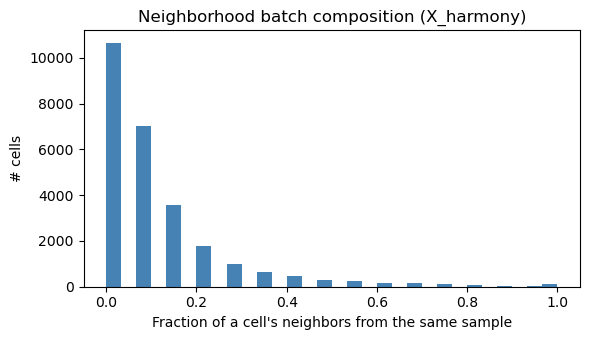

In [4]:
# Request one extra neighbor: NearestNeighbors.kneighbors(embedding) queries with the
# same array used to fit, so sklearn returns each point itself (distance 0) as its own
# first "neighbor." Drop that self-match and keep exactly N_NEIGHBORS true neighbors.
nn = NearestNeighbors(n_neighbors=N_NEIGHBORS + 1).fit(embedding)
_, raw_neighbor_idx = nn.kneighbors(embedding)

neighbor_idx = np.vstack([
    row[row != i][:N_NEIGHBORS]
    for i, row in enumerate(raw_neighbor_idx)
])   # (n_cells, N_NEIGHBORS) positions into cell_names/embedding — self excluded

same_sample_frac = np.array([
    (samples_full.iloc[neighbor_idx[i]].to_numpy() == samples_full.iloc[i]).mean()
    for i in range(len(cell_names))
])

print(f"Neighbor graph: {N_NEIGHBORS} neighbors per cell on {EMBEDDING_KEY}[:, :{EMBEDDING_DIMS}] (self excluded)")
print(f"Same-sample neighbor fraction: mean={same_sample_frac.mean():.3f}, "
      f"median={np.median(same_sample_frac):.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(same_sample_frac, bins=30, color='steelblue')
ax.set(xlabel="Fraction of a cell's neighbors from the same sample",
       ylabel='# cells',
       title=f'Neighborhood batch composition ({EMBEDDING_KEY})')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'neighborhood_batch_composition.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4. Discover usable K values

Every downstream validation in this notebook joins against NB1's and NB2's and NB4's outputs, so we restrict the whole sweep to K values where **all four** sources exist — rather than silently dropping rows later. `gep_program_class.tsv` and the cNMF usage files cover K=3–35

In [5]:
def usage_path(k):
    return os.path.join(CNMF_DIR, f"{CNMF_PREFIX}.usages.k_{k}.dt_{DENSITY_THRESHOLD}.consensus.txt")

usage_pattern = os.path.join(CNMF_DIR, f"{CNMF_PREFIX}.usages.k_*.dt_{DENSITY_THRESHOLD}.consensus.txt")
k_usage = {int(m.group(1)) for f in glob.glob(usage_pattern)
           if (m := re.search(r'k_(\d+)', os.path.basename(f)))}

labels_df = pd.read_csv(LABELS_PATH, sep='\t')
labels_df['k'] = labels_df['k'].astype(int)
labels_df['gep'] = labels_df['gep'].astype(str)
k_labels = set(labels_df['k'].unique())

program_class_df = pd.read_csv(PROGRAM_CLASS_PATH, sep='\t')
program_class_df['k'] = program_class_df['k'].astype(int)
program_class_df['gep'] = program_class_df['gep'].astype(str)
k_program_class = set(program_class_df['k'].unique())

rogue_df = pd.read_csv(ROGUE_SPLIT_MERGE_PATH)
rogue_df['K'] = rogue_df['K'].astype(int)
rogue_df['gep'] = rogue_df['gep'].astype(str)
k_rogue = set(rogue_df['K'].unique())

requested = set(range(K_MIN, K_MAX + 1))
k_values = sorted(k_usage & k_labels & k_program_class & k_rogue & requested)
dropped = sorted(((k_usage | k_labels | k_program_class | k_rogue) & requested) - set(k_values))

print(f"Usable K values (usage ∩ per_gep_labels ∩ gep_program_class ∩ ROGUE, within [{K_MIN},{K_MAX}]): {k_values}")
if dropped:
    print(f"Dropped (present in some but not all sources): {dropped}")

Usable K values (usage ∩ per_gep_labels ∩ gep_program_class ∩ ROGUE, within [3,35]): [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


### 5. GPN core math — per-cell program interaction graph

For each cell *i* at a given K, with raw usage vector `u_i` (non-negative, length K) and its `N_NEIGHBORS` nearest cells in Harmony space:

- **Coherence graph** `C_i` — Pearson correlation between GEPs computed *within the neighborhood*, on z-scored usage (z-scoring is across all cells, per GEP; the correlation itself is local).
- **Activation weights** `W_i = outer(u_i, u_i)` — magnitude gating from the cell's own raw usage (already non-negative, so no ReLU step is needed here unlike the paper's score-based activities).
- **Interaction graph** `G_i = C_i ⊙ W_i`.
- **Coherence** `= sum(G_i, off-diag) / sum(|W_i|, off-diag)`.
- **Conflict** `= sum(|G_i|, off-diag, G_i<0) / sum(|W_i|, off-diag)`.
- **Total activity** `A_i = sum(u_i)`; **dominance share** `= max(u_i)/A_i`; **diversity** `D_i = exp(Shannon entropy of u_i/A_i)`.
- **GPCI** `= coherence × log(1+A_i) × D_i/K`.

Cached to `OUT_DIR/gpn_metrics_K{k}.csv` per K, the same cache-if-exists pattern NB4 uses for its ROGUE tables.

In [6]:
def load_usage(k):
    u = pd.read_csv(usage_path(k), sep='\t', index_col=0)
    u.index = u.index.astype(str)
    u.columns = u.columns.astype(str)
    return u

def compute_gpn_for_k(k, out_path):
    """Per-cell GPCI, conflict, diversity, dominance, activity, and dominant GEP for one K."""
    if os.path.exists(out_path) and not FORCE_RECOMPUTE:
        # 'gep' is a digit string ("1".."35") everywhere else in the pipeline, so pin
        # it here too — otherwise a bare read_csv infers int64 and the ['K','gep']
        # merges in 9/10 silently drop every row from this cache branch.
        return pd.read_csv(out_path, index_col=0, dtype={'gep': str})

    usage = load_usage(k)
    common = [c for c in usage.index if c in cell_to_pos]
    usage = usage.loc[common]

    U = usage.to_numpy(dtype=np.float64)               # raw, non-negative: cells x programs
    n_cells, n_prog = U.shape
    positions = np.array([cell_to_pos[c] for c in usage.index])
    pos_to_row = {p: r for r, p in enumerate(positions)}

    # z-scored usage — used only for the local correlation graph
    mu, sd = U.mean(axis=0), U.std(axis=0)
    sd_safe = np.where(sd > 0, sd, 1.0)
    Z = (U - mu) / sd_safe

    total_activity = U.sum(axis=1)                      # A_i
    with np.errstate(divide='ignore', invalid='ignore'):
        shares = np.where(total_activity[:, None] > 0, U / total_activity[:, None], 0.0)
    dominance_share = shares.max(axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        plogp = np.where(shares > 0, shares * np.log(shares), 0.0)
    diversity = np.exp(-plogp.sum(axis=1))               # D_i, effective # active programs

    off_diag = ~np.eye(n_prog, dtype=bool)
    coherence = np.full(n_cells, np.nan)
    conflict = np.full(n_cells, np.nan)

    for r in tqdm(range(n_cells), desc=f"GPN graphs K={k}"):
        full_pos = positions[r]
        nb_rows = [pos_to_row[p] for p in neighbor_idx[full_pos] if p in pos_to_row]
        if len(nb_rows) < MIN_NEIGHBORS_FOR_GRAPH:
            continue
        with np.errstate(invalid='ignore'):
            C = np.corrcoef(Z[nb_rows], rowvar=False)
        C = np.nan_to_num(C, nan=0.0)
        W = np.outer(U[r], U[r])
        G = C * W
        w_abs_sum = np.abs(W[off_diag]).sum()
        if w_abs_sum == 0:
            coherence[r] = 0.0
            conflict[r] = 0.0
            continue
        coherence[r] = G[off_diag].sum() / w_abs_sum
        neg_mask = G[off_diag] < 0
        conflict[r] = np.abs(G[off_diag][neg_mask]).sum() / w_abs_sum

    gpci = coherence * np.log1p(total_activity) * (diversity / n_prog)
    dominant_gep = usage.columns.to_numpy()[U.argmax(axis=1)]

    df = pd.DataFrame({
        'cell': usage.index, 'K': k, 'gep': dominant_gep,
        'activity': total_activity, 'dominance_share': dominance_share,
        'coherence': coherence, 'conflict': conflict,
        'diversity': diversity, 'GPCI': gpci,
    }).set_index('cell')
    df['gep'] = df['gep'].astype(str)
    df.to_csv(out_path)
    return df

print("GPN core functions defined.")

GPN core functions defined.


### 6. Compute GPN metrics for every K

In [7]:
gpn_metrics_parts = []
for k in k_values:
    out_path = os.path.join(OUT_DIR, f"gpn_metrics_K{k}.csv")
    gpn_metrics_parts.append(compute_gpn_for_k(k, out_path))

gpn_metrics = pd.concat(gpn_metrics_parts, ignore_index=False).reset_index()
gpn_metrics['gep'] = gpn_metrics['gep'].astype(str)  # keep 'gep' a string across all K's
gpn_metrics['sample'] = gpn_metrics['cell'].map(samples_full)

print(f"{len(gpn_metrics)} (cell, K) rows across K = {k_values}")
gpn_metrics[['activity', 'dominance_share', 'coherence', 'conflict', 'diversity', 'GPCI']].describe().round(3)

872652 (cell, K) rows across K = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


,activity,dominance_share,coherence,conflict,diversity,GPCI
count,872652.000,872652.000,872652.000,872652.000,872652.000,872652.000
mean,511.131,0.593,0.182,0.080,3.610,0.227
std,463.605,0.223,0.267,0.097,1.928,0.438
min,9.800,0.117,-0.879,0.000,1.000,-3.921
25%,203.883,0.410,0.000,0.009,2.105,0.000
50%,383.643,0.569,0.161,0.046,3.279,0.168
75%,669.564,0.778,0.361,0.115,4.719,0.400
max,7463.375,1.000,0.986,0.879,13.521,6.585


### 7. Threshold diagnostic

Before locking in state assignments, look at where this dataset's activity / dominance / conflict / GPCI distributions actually sit relative to the paper's default cutoffs — the same practice NB1 7.2–7.3 uses for its own GSEA thresholds. If a line falls somewhere that doesn't look like a meaningful cutpoint in this dataset's distribution, adjust the corresponding `*_PERCENTILE` / `DOMINANCE_FRACTION` constant in 1 and re-run from this cell — 6's cached per-K files don't need to be rebuilt, since none of this touches the graph computation.

Pooled quantiles across all K (for reference only — classification below uses per-K percentiles):
     activity  dominance_share  conflict   GPCI
0.2   174.087            0.375     0.005 -0.038
0.5   383.643            0.569     0.046  0.168
0.6   479.368            0.637     0.068  0.247
0.7   598.355            0.728     0.097  0.342
0.8   757.503            0.828     0.138  0.467
0.9  1034.022            0.925     0.208  0.663


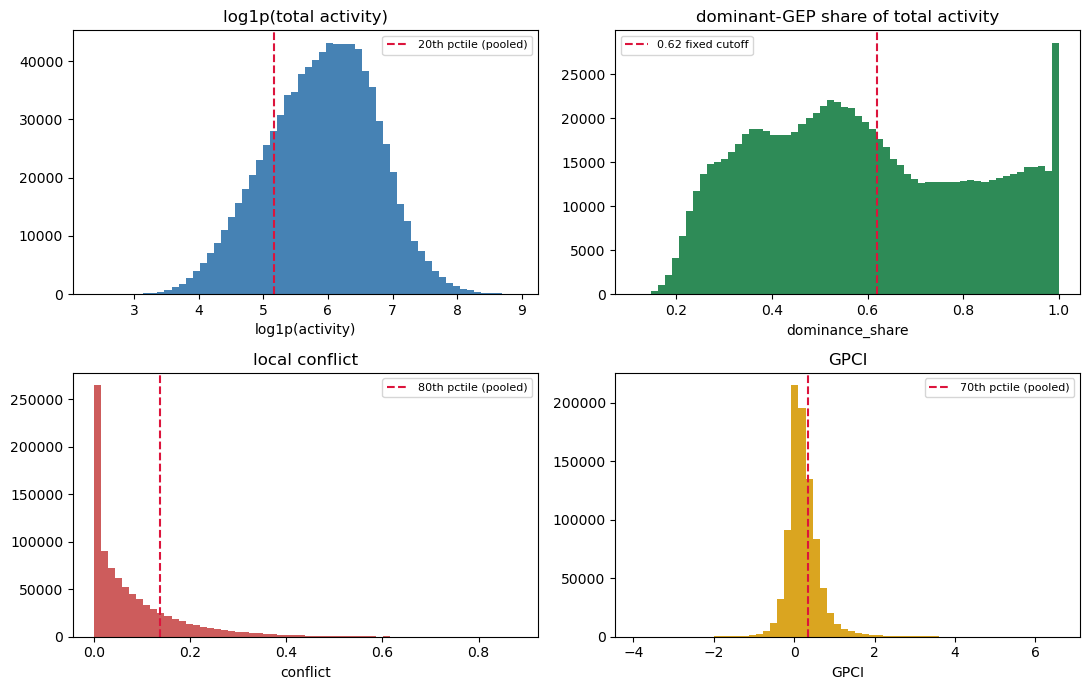

In [8]:
pooled = gpn_metrics
print("Pooled quantiles across all K (for reference only — classification below uses per-K percentiles):")
print(pooled[['activity', 'dominance_share', 'conflict', 'GPCI']].quantile([.2, .5, .6, .7, .8, .9]).round(3).to_string())

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

axes[0].hist(np.log1p(pooled['activity']), bins=60, color='steelblue')
axes[0].axvline(np.log1p(np.percentile(pooled['activity'], LOW_ACTIVITY_PERCENTILE)),
                color='crimson', ls='--', label=f'{LOW_ACTIVITY_PERCENTILE}th pctile (pooled)')
axes[0].set(title='log1p(total activity)', xlabel='log1p(activity)'); axes[0].legend(fontsize=8)

axes[1].hist(pooled['dominance_share'], bins=60, color='seagreen')
axes[1].axvline(DOMINANCE_FRACTION, color='crimson', ls='--', label=f'{DOMINANCE_FRACTION} fixed cutoff')
axes[1].set(title='dominant-GEP share of total activity', xlabel='dominance_share'); axes[1].legend(fontsize=8)

axes[2].hist(pooled['conflict'].dropna(), bins=60, color='indianred')
axes[2].axvline(np.percentile(pooled['conflict'].dropna(), COMPETITION_PERCENTILE),
                color='crimson', ls='--', label=f'{COMPETITION_PERCENTILE}th pctile (pooled)')
axes[2].set(title='local conflict', xlabel='conflict'); axes[2].legend(fontsize=8)

axes[3].hist(pooled['GPCI'].dropna(), bins=60, color='goldenrod')
axes[3].axvline(np.percentile(pooled['GPCI'].dropna(), CONSENSUS_GPCI_PERCENTILE),
                color='crimson', ls='--', label=f'{CONSENSUS_GPCI_PERCENTILE}th pctile (pooled)')
axes[3].set(title='GPCI', xlabel='GPCI'); axes[3].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'threshold_diagnostic.png'), dpi=150, bbox_inches='tight')
plt.show()

#### 7.1 `dominance_share`, redrawn per K

The pooled panel above mixes every K (3–35) into one histogram, which can hide K-dependent structure. That's a real concern specifically for `dominance_share`: with few GEPs (low K) it's mechanically easy for one program to soak up nearly all of a cell's usage, whereas with many GEPs (high K) activity is spread thinner and dominance_share is naturally lower — so a single pooled histogram is really a mixture of very different regimes. Redrawing the same distribution separately for each K, with the same fixed `DOMINANCE_FRACTION` line, shows whether 0.62 is a consistent, meaningful cutpoint across resolutions or whether its effect (the fraction of cells it sweeps into Dominance) swings wildly with K — which would explain the state-composition swings seen later in 8.

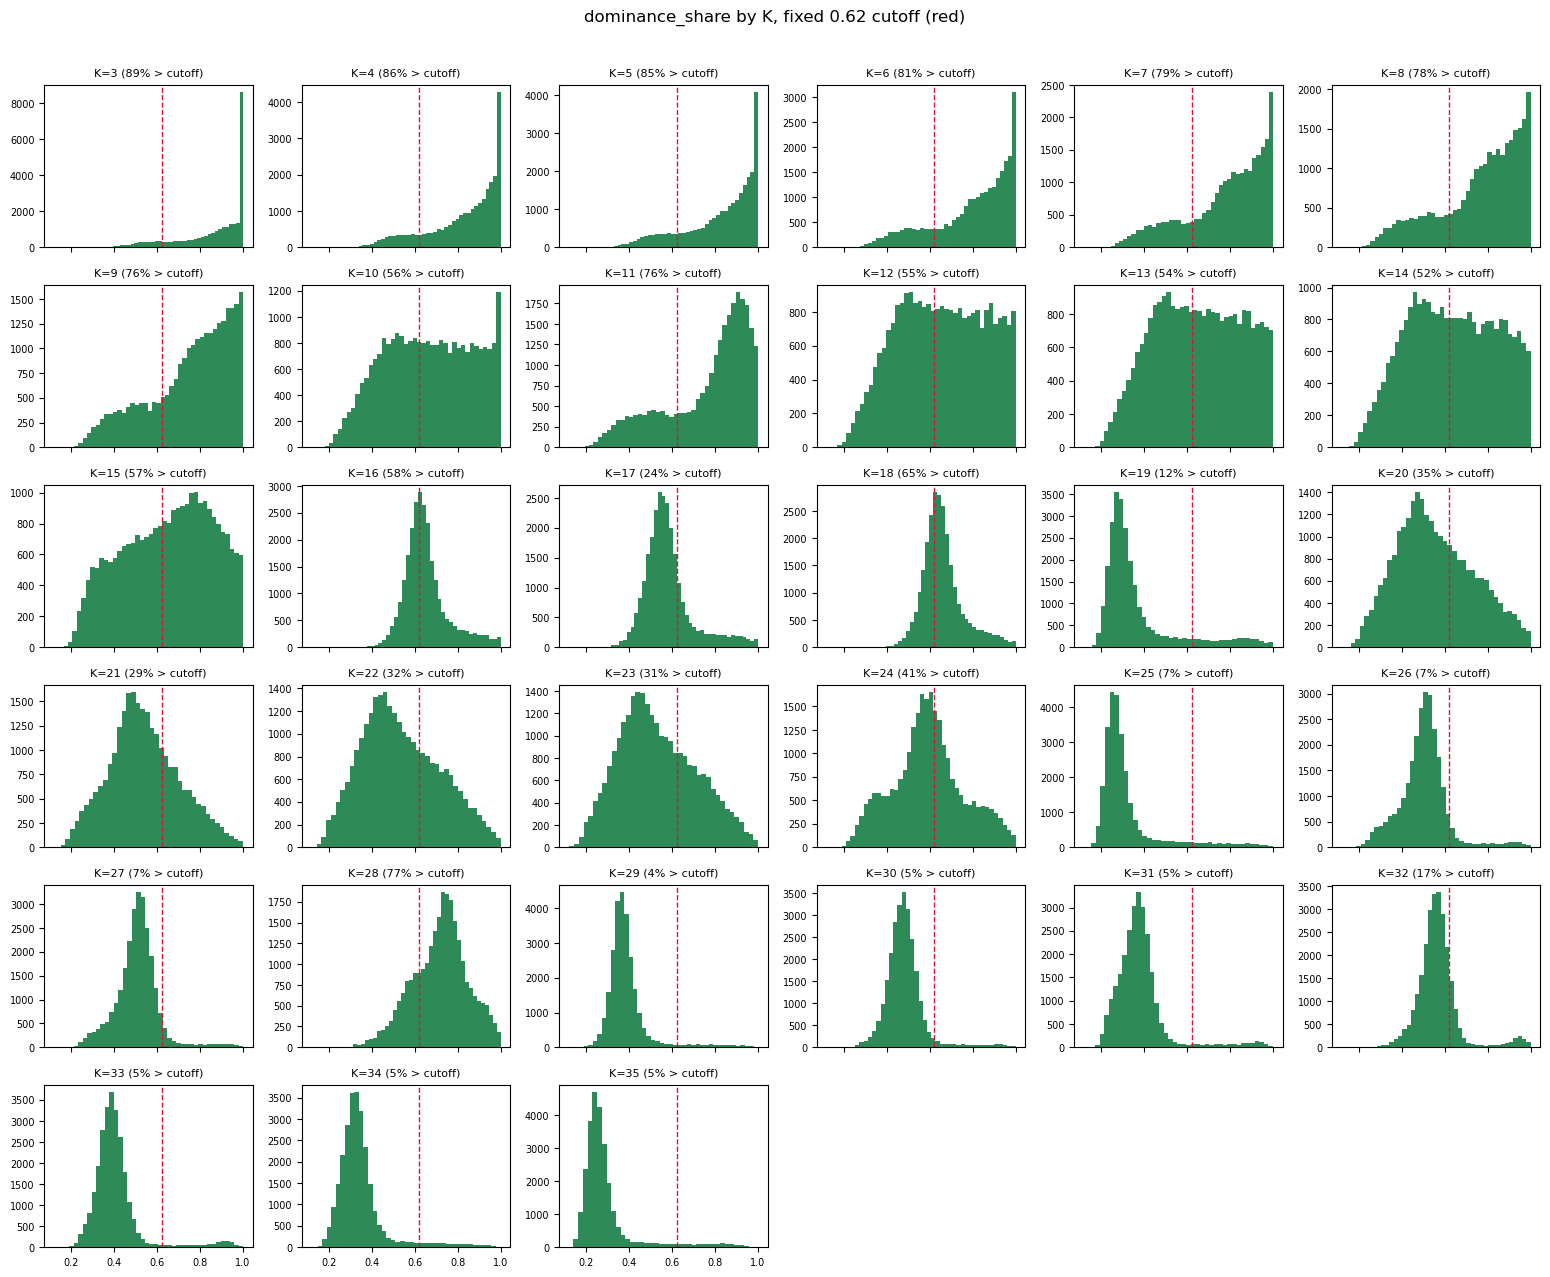

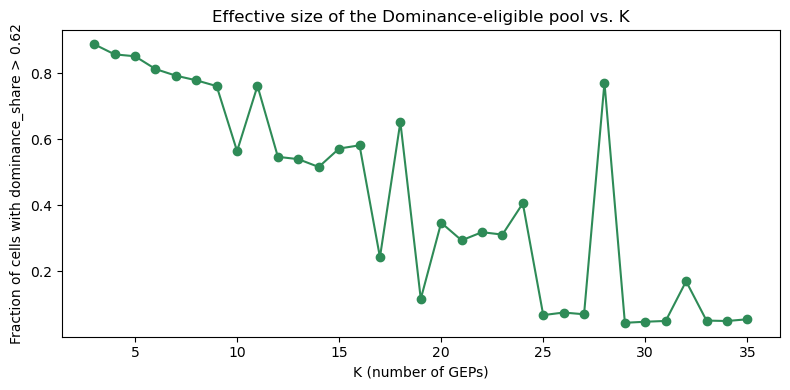

 K  n_cells  frac_above_cutoff
 3    26444              0.888
 4    26444              0.857
 5    26444              0.851
 6    26444              0.813
 7    26444              0.792
 8    26444              0.778
 9    26444              0.761
10    26444              0.564
11    26444              0.761
12    26444              0.546
13    26444              0.539
14    26444              0.516
15    26444              0.572
16    26444              0.581
17    26444              0.242
18    26444              0.652
19    26444              0.116
20    26444              0.347
21    26444              0.293
22    26444              0.318
23    26444              0.311
24    26444              0.405
25    26444              0.067
26    26444              0.075
27    26444              0.069
28    26444              0.771
29    26444              0.043
30    26444              0.047
31    26444              0.049
32    26444              0.169
33    26444              0.050
34    26

In [9]:
n_k = len(k_values)
n_cols = 6
n_rows = int(np.ceil(n_k / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.6, n_rows * 2.1), sharex=True)
axes = axes.flatten()

frac_above_rows = []
for ax, k in zip(axes, k_values):
    sub = gpn_metrics.loc[gpn_metrics['K'] == k, 'dominance_share'].dropna()
    frac_above = (sub > DOMINANCE_FRACTION).mean()
    frac_above_rows.append({'K': k, 'n_cells': len(sub), 'frac_above_cutoff': frac_above})

    ax.hist(sub, bins=40, color='seagreen')
    ax.axvline(DOMINANCE_FRACTION, color='crimson', ls='--', lw=1)
    ax.set_title(f'K={k} ({frac_above:.0%} > cutoff)', fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes[n_k:]:
    ax.axis('off')

fig.suptitle(f"dominance_share by K, fixed {DOMINANCE_FRACTION} cutoff (red)", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'dominance_share_by_K.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary: how much of each K's population the fixed cutoff sweeps into Dominance —
# this is the number that actually drives 8's per-K state composition.
frac_above_df = pd.DataFrame(frac_above_rows)
frac_above_df.to_csv(os.path.join(OUT_DIR, 'dominance_share_frac_above_cutoff_by_K.csv'), index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(frac_above_df['K'], frac_above_df['frac_above_cutoff'], marker='o', color='seagreen')
ax.set(xlabel='K (number of GEPs)',
       ylabel=f'Fraction of cells with dominance_share > {DOMINANCE_FRACTION}',
       title='Effective size of the Dominance-eligible pool vs. K')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'dominance_share_frac_above_cutoff_by_K.png'), dpi=150, bbox_inches='tight')
plt.show()

print(frac_above_df.round(3).to_string(index=False))
print(
    "\nIf frac_above_cutoff is high at low K and low at high K, the fixed 0.62 cutoff isn't a "
    "resolution-independent rule — it's effectively a much looser filter at low K than at high K. "
    "Consider a per-K percentile-based dominance cutoff (like the other three thresholds) instead "
    "of a single fixed fraction if that pattern shows up here."
)

### 8. Classify regulatory decision states

Thresholds are computed **per K** (each K has a different number of GEPs, so pooling percentiles across K would mix incomparable scales), then applied as a strict priority order — exactly the if/elif chain in the paper's Methods, where an earlier rule always wins over a later one:

`Low activity` (bottom `LOW_ACTIVITY_PERCENTILE`% activity) > `Dominance` (dominant share > `DOMINANCE_FRACTION`) > `Competition` (top `COMPETITION_PERCENTILE`% conflict) > `Consensus` (GPCI ≥ `CONSENSUS_GPCI_PERCENTILE`th pctile AND conflict ≤ `CONSENSUS_CONFLICT_PERCENTILE`th pctile) > else `Negotiation`.

state  Low activity  Dominance  Competition  Consensus  Negotiation
K                                                                  
3               0.2      0.699        0.025      0.052        0.024
4               0.2      0.672        0.031      0.051        0.045
5               0.2      0.667        0.031      0.057        0.044
6               0.2      0.631        0.036      0.069        0.065
7               0.2      0.613        0.037      0.076        0.074
8               0.2      0.601        0.043      0.078        0.079
9               0.2      0.586        0.043      0.085        0.086
10              0.2      0.450        0.050      0.154        0.146
11              0.2      0.585        0.047      0.087        0.081
12              0.2      0.437        0.055      0.154        0.154
13              0.2      0.433        0.056      0.157        0.154
14              0.2      0.412        0.059      0.167        0.162
15              0.2      0.447        0.049     

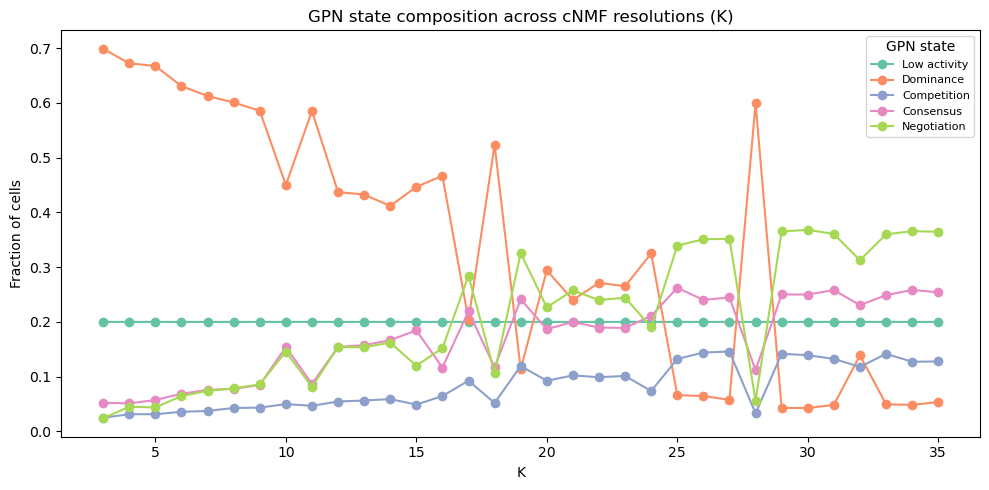

In [10]:
def classify_states(df):
    out = df.copy()
    out['state'] = None
    for k, idx in out.groupby('K').groups.items():
        sub = out.loc[idx]
        low_cut = np.percentile(sub['activity'], LOW_ACTIVITY_PERCENTILE)
        comp_cut = np.percentile(sub['conflict'].dropna(), COMPETITION_PERCENTILE)
        gpci_cut = np.percentile(sub['GPCI'].dropna(), CONSENSUS_GPCI_PERCENTILE)
        cons_conflict_cut = np.percentile(sub['conflict'].dropna(), CONSENSUS_CONFLICT_PERCENTILE)

        # Applied in reverse priority so the highest-priority rule is written last and wins.
        state = pd.Series('Negotiation', index=sub.index)
        state[(sub['GPCI'] >= gpci_cut) & (sub['conflict'] <= cons_conflict_cut)] = 'Consensus'
        state[sub['conflict'] >= comp_cut] = 'Competition'
        state[sub['dominance_share'] > DOMINANCE_FRACTION] = 'Dominance'
        state[sub['activity'] <= low_cut] = 'Low activity'
        out.loc[idx, 'state'] = state
    return out

gpn_states = classify_states(gpn_metrics)
state_by_k = gpn_states.groupby('K')['state'].value_counts(normalize=True).unstack()[STATE_ORDER]
print(state_by_k.round(3).to_string())

# State composition swings sharply with K (e.g. Dominance ranges from ~70% at K=3 to
# ~4% at K~29) — every downstream comparison that pools across K should be read
# alongside this, not instead of it.
ax = state_by_k.plot(figsize=(10, 5), marker='o',
                      color=sns.color_palette('Set2', n_colors=len(STATE_ORDER)))
ax.set(xlabel='K', ylabel='Fraction of cells',
       title='GPN state composition across cNMF resolutions (K)')
ax.legend(title='GPN state', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'state_composition_by_K.png'), dpi=150, bbox_inches='tight')
plt.show()

**Coverage check** (mirrors NB1 7.6): every cell scored gets exactly one valid state, and no K silently lost cells during the `cell_to_pos` intersection in 5.

In [11]:
VALID_STATES = set(STATE_ORDER)
problems = []

bad_states = set(gpn_states['state'].dropna().unique()) - VALID_STATES
if bad_states:
    problems.append(f"invalid state value(s): {bad_states}")
n_missing = gpn_states['state'].isna().sum()
if n_missing:
    problems.append(f"{n_missing} rows with no state assigned")

for k in k_values:
    n_usage_cells = len(load_usage(k).index)
    n_scored = (gpn_states['K'] == k).sum()
    if n_scored < 0.99 * n_usage_cells:
        problems.append(f"K={k}: only {n_scored}/{n_usage_cells} usage-matrix cells were scored "
                         f"(likely missing from adata/{EMBEDDING_KEY})")

if problems:
    print("Coverage check found issues:\n  - " + "\n  - ".join(problems))
else:
    print(f"✓ Coverage check passed: {len(gpn_states)} (cell,K) rows, "
          f"all states valid, ≥99% of usage-matrix cells scored at every K.")

✓ Coverage check passed: 872652 (cell,K) rows, all states valid, ≥99% of usage-matrix cells scored at every K.


### 9. Validation A — GPN states vs. NB2 dominant-program identity

Each cell's dominant GEP (its own argmax usage, computed in 5) is looked up against NB2's `per_gep_labels.tsv` to get that GEP's cell-type identity — the same "dominant program" axis as the paper's Fig. 3A/6A. If a single identity label spans multiple GPN states, and GPCI varies significantly within it, that reproduces the paper's central claim: dominant program identity alone does not determine regulatory organization.

The Kruskal–Wallis test below pools all K together; since state composition itself shifts substantially with K (8), a per-K version is also reported so pooled significance can't be driven by a handful of resolutions.

0.0% of (cell,K) rows have no NB2 label (unexpected gep id) — should be ~0%.


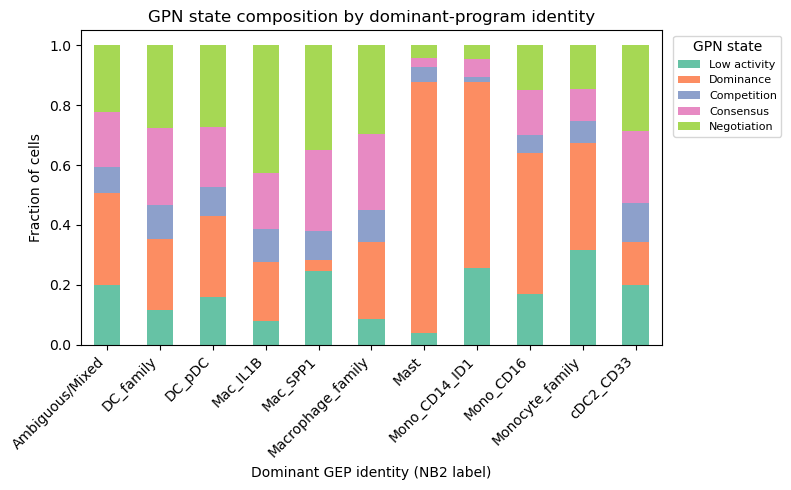


Pooled Kruskal–Wallis, GPCI across dominant-program labels: H=64857.7, p=0
A label spanning multiple GPN states (bars above not solid) plus a significant GPCI difference reproduce the paper's Fig. 3C/D and 6C.

Per-K Kruskal–Wallis: significant (p<0.05) at 30/30 K values


In [12]:
gpn_states = gpn_states.merge(
    labels_df.rename(columns={'k': 'K'})[['K', 'gep', 'label']],
    on=['K', 'gep'], how='left'
)
print(f"{gpn_states['label'].isna().mean():.1%} of (cell,K) rows have no NB2 label (unexpected gep id) — should be ~0%.")

state_by_label = pd.crosstab(gpn_states['label'], gpn_states['state'], normalize='index')[STATE_ORDER]
state_by_label.to_csv(os.path.join(OUT_DIR, 'state_composition_by_label.csv'))

fig, ax = plt.subplots(figsize=(max(8, len(state_by_label) * 0.6), 5))
state_by_label.plot(kind='bar', stacked=True, ax=ax,
                     color=sns.color_palette('Set2', n_colors=len(STATE_ORDER)))
ax.set(ylabel='Fraction of cells', xlabel='Dominant GEP identity (NB2 label)',
       title='GPN state composition by dominant-program identity')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='GPN state', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'state_composition_by_label.png'), dpi=150, bbox_inches='tight')
plt.show()

groups = [g['GPCI'].dropna().to_numpy() for _, g in gpn_states.groupby('label') if g['GPCI'].notna().sum() >= 10]
stat, p = kruskal(*groups)
print(f"\nPooled Kruskal–Wallis, GPCI across dominant-program labels: H={stat:.1f}, p={p:.3g}")
print("A label spanning multiple GPN states (bars above not solid) plus a significant GPCI difference "
      "reproduce the paper's Fig. 3C/D and 6C.")

# Per-K version — is the pooled result driven by a handful of resolutions, or consistent?
per_k_kw_rows = []
for k, sub in gpn_states.groupby('K'):
    k_groups = [g['GPCI'].dropna().to_numpy() for _, g in sub.groupby('label') if g['GPCI'].notna().sum() >= 10]
    if len(k_groups) < 2:
        continue
    k_stat, k_p = kruskal(*k_groups)
    per_k_kw_rows.append({'K': k, 'n_labels_tested': len(k_groups), 'H': k_stat, 'p': k_p})

per_k_kw = pd.DataFrame(per_k_kw_rows)
per_k_kw.to_csv(os.path.join(OUT_DIR, 'validation_A_per_K_kruskal.csv'), index=False)
print(f"\nPer-K Kruskal–Wallis: significant (p<0.05) at {(per_k_kw['p'] < 0.05).sum()}/{len(per_k_kw)} K values")

### 10. Validation B — GPN states vs. NB1 identity confidence

NB1 already flags which (K, GEP) pairs have *no* significant cell-type enrichment at all (`non_identity_unresolved`) versus a confident call (`identity_supported` / `identity_ambiguous`). The paper has no equivalent independent confidence label, so there's no basis in the paper for assuming a particular GPN state should follow from a given `program_class` — a `non_identity_unresolved` GEP (no cell-type gene set match) could still show coherent cross-program co-activation (e.g. a shared interferon, stress, or metabolic program) and legitimately land in Consensus. This is therefore an **exploratory** cross-tabulation of two independently-derived per-(K,GEP) labels, not a check with a predicted right answer.

In [13]:
gpn_states = gpn_states.merge(
    program_class_df.rename(columns={'k': 'K'})[['K', 'gep', 'program_class']],
    on=['K', 'gep'], how='left'
)

ct = pd.crosstab(gpn_states['program_class'], gpn_states['state'])[STATE_ORDER]
print(ct.to_string())
chi2, p, dof, _ = chi2_contingency(ct)
n_obs = ct.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n_obs * (min(ct.shape) - 1)))
print(f"\nChi-square (program_class x GPN state): chi2={chi2:.1f}, dof={dof}, p={p:.3g}, "
      f"Cramér's V={cramers_v:.3f}")
print("Cramér's V (0=no association, 1=perfect) matters more than the p-value here — with "
      f"n={n_obs:,} rows, even a tiny association is 'significant'.")

unresolved = gpn_states['program_class'] == 'non_identity_unresolved'
uncertain_state = gpn_states['state'].isin(['Low activity', 'Negotiation'])
table_2x2 = pd.crosstab(unresolved, uncertain_state)
odds_ratio, p_fisher = fisher_exact(table_2x2)
print(f"\n2x2: non_identity_unresolved x {{Low activity, Negotiation}} — "
      f"odds ratio={odds_ratio:.2f}, Fisher p={p_fisher:.3g} (exploratory — see 10 markdown)")

ct.to_csv(os.path.join(OUT_DIR, 'state_vs_program_class.csv'))

# Per-K version of the same association, to check whether it's consistent across resolutions.
per_k_cramers_rows = []
for k, sub in gpn_states.groupby('K'):
    k_ct = pd.crosstab(sub['program_class'], sub['state'])
    if k_ct.shape[0] < 2 or k_ct.shape[1] < 2:
        continue
    k_chi2, k_p, _, _ = chi2_contingency(k_ct)
    k_n = k_ct.to_numpy().sum()
    k_v = np.sqrt(k_chi2 / (k_n * (min(k_ct.shape) - 1)))
    per_k_cramers_rows.append({'K': k, 'chi2': k_chi2, 'p': k_p, 'cramers_v': k_v})

per_k_cramers = pd.DataFrame(per_k_cramers_rows)
per_k_cramers.to_csv(os.path.join(OUT_DIR, 'validation_B_per_K_cramers_v.csv'), index=False)
print(f"\nPer-K Cramér's V: median={per_k_cramers['cramers_v'].median():.3f}, "
      f"range=[{per_k_cramers['cramers_v'].min():.3f}, {per_k_cramers['cramers_v'].max():.3f}]")

state                    Low activity  Dominance  Competition  Consensus  Negotiation
program_class                                                                        
identity_ambiguous             115633     154630        42184      94103       113113
identity_supported              44666     106293        15740      34515        37856
non_identity_unresolved         14239      33911        14613      20836        30320

Chi-square (program_class x GPN state): chi2=25829.5, dof=8, p=0, Cramér's V=0.122
Cramér's V (0=no association, 1=perfect) matters more than the p-value here — with n=872,652 rows, even a tiny association is 'significant'.

2x2: non_identity_unresolved x {Low activity, Negotiation} — odds ratio=0.92, Fisher p=1.6e-34 (exploratory — see 10 markdown)

Per-K Cramér's V: median=0.245, range=[0.116, 0.416]


### 11. Comparison C — GPN organization vs. NB4 ROGUE purity (independent signal)

ROGUE and GPN describe different levels of organization: ROGUE scores whether a *group* of cells (a sample × K × GEP bin) is transcriptionally homogeneous, while GPN's conflict/GPCI describe how programs are organized *within* individual cells. A group can be internally homogeneous (high ROGUE) while every cell in it carries the same internal program conflict — so there's no paper-derived prediction for which direction this correlation should run, and it does not have to be negative for GPN to be doing something real. ROGUE is computed independently of GPN's outputs so this is a genuinely external comparison — but it's a comparison, not a validation with a predicted sign.

6211 (sample, K, GEP) groups joined against ROGUE (of 14446 GPN groups, 6211 ROGUE rows)
  Pooled Spearman(competition_frac, ROGUE) = -0.034  (p=0.00764, n=6211)
  Pooled Spearman(mean_conflict, ROGUE) = 0.303  (p=4.78e-132, n=6211)
  Pooled Spearman(mean_GPCI, ROGUE) = -0.440  (p=4.47e-292, n=6211)


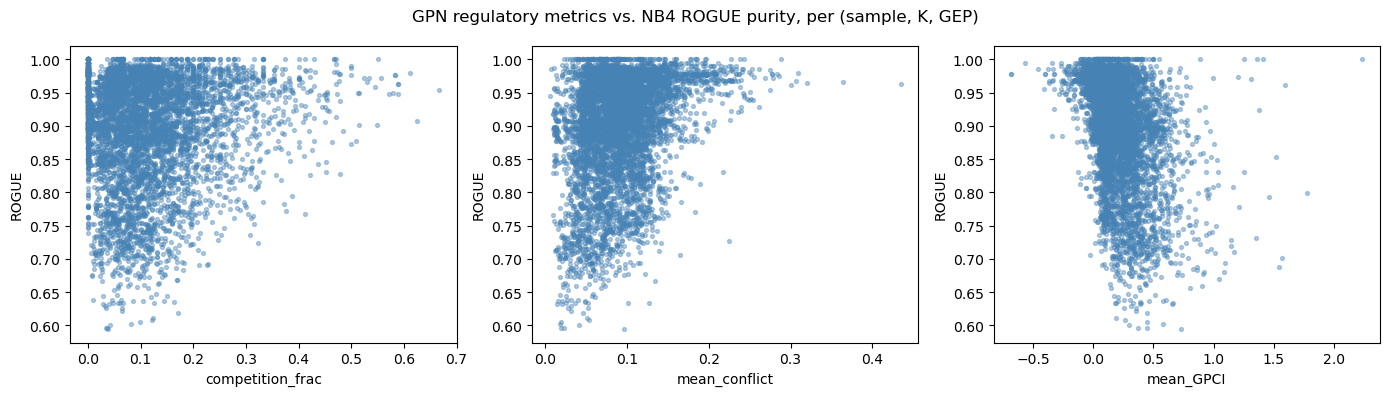

  competition_frac: pooled rho sign matches 61% of per-K rhos (median per-K rho=-0.063)
  mean_conflict: pooled rho sign matches 100% of per-K rhos (median per-K rho=0.344)
  mean_GPCI: pooled rho sign matches 100% of per-K rhos (median per-K rho=-0.504)


In [14]:
agg = (gpn_states.groupby(['sample', 'K', 'gep'])
       .agg(n_cells=('state', 'size'),
            competition_frac=('state', lambda s: (s == 'Competition').mean()),
            consensus_frac=('state', lambda s: (s == 'Consensus').mean()),
            mean_GPCI=('GPCI', 'mean'),
            mean_conflict=('conflict', 'mean'))
       .reset_index())

rogue = rogue_df[['sample', 'K', 'gep', 'ROGUE', 'baseline_ROGUE', 'delta_ROGUE', 'recommendation']]
contam = pd.read_csv(ROGUE_CONTAMINATION_PATH)
contam['K'] = contam['K'].astype(int)
contam['gep'] = contam['gep'].astype(str)
contam = contam[['sample', 'K', 'gep', 'contamination_delta']]

merged = (agg.merge(rogue, on=['sample', 'K', 'gep'], how='inner')
             .merge(contam, on=['sample', 'K', 'gep'], how='left'))
merged.to_csv(os.path.join(OUT_DIR, 'gpn_vs_rogue.csv'), index=False)
print(f"{len(merged)} (sample, K, GEP) groups joined against ROGUE (of {len(agg)} GPN groups, "
      f"{len(rogue)} ROGUE rows)")

pooled_corrs = {}
for x, y in [('competition_frac', 'ROGUE'), ('mean_conflict', 'ROGUE'), ('mean_GPCI', 'ROGUE')]:
    sub = merged[[x, y]].dropna()
    rho, p = spearmanr(sub[x], sub[y])
    pooled_corrs[x] = rho
    print(f"  Pooled Spearman({x}, {y}) = {rho:.3f}  (p={p:.3g}, n={len(sub)})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (x, y) in zip(axes, [('competition_frac', 'ROGUE'), ('mean_conflict', 'ROGUE'), ('mean_GPCI', 'ROGUE')]):
    ax.scatter(merged[x], merged[y], s=8, alpha=0.4, color='steelblue')
    ax.set(xlabel=x, ylabel=y)
plt.suptitle('GPN regulatory metrics vs. NB4 ROGUE purity, per (sample, K, GEP)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'gpn_vs_rogue.png'), dpi=150, bbox_inches='tight')
plt.show()

# Per-K correlations — is the pooled direction consistent across resolutions, or an artifact of pooling?
per_k_corr_rows = []
for k, sub in merged.groupby('K'):
    for metric in ['competition_frac', 'mean_conflict', 'mean_GPCI']:
        valid = sub[[metric, 'ROGUE']].dropna()
        if len(valid) < 10:
            continue
        rho, p = spearmanr(valid[metric], valid['ROGUE'])
        per_k_corr_rows.append({'K': k, 'metric': metric, 'rho': rho, 'p': p, 'n': len(valid)})

per_k_corr = pd.DataFrame(per_k_corr_rows)
per_k_corr.to_csv(os.path.join(OUT_DIR, 'comparison_C_per_K_spearman.csv'), index=False)

for metric in ['competition_frac', 'mean_conflict', 'mean_GPCI']:
    m = per_k_corr[per_k_corr['metric'] == metric]
    same_sign = (np.sign(m['rho']) == np.sign(pooled_corrs[metric])).mean()
    print(f"  {metric}: pooled rho sign matches {same_sign:.0%} of per-K rhos "
          f"(median per-K rho={m['rho'].median():.3f})")

### 12. GEP negotiation profile — win rate and chief rival

Every validation so far stays at the level of the individual cell: does its GPN state track its dominant-program identity (9), its GSEA confidence (10), its group's ROGUE purity (11)? NB6's actual decision, though, is about a GEP/label, not a cell. This section re-aggregates the same per-cell outputs already computed in 5/6/8 up to the (K, GEP) grain NB6 works at, and asks two GEP-level questions instead of a cell-level one:

- **`win_rate`** — of the cells where this GEP is the dominant program, what fraction settle into a clear regulatory identity (Consensus/Dominance) versus stay contested (Competition/Negotiation)? Low-activity cells are excluded from the denominator — insufficient signal to call a "win" or a "contest" either way. A program that rarely settles is one whose cells never really commit to it as an identity, independent of whatever ROGUE says about the group's transcriptional homogeneity.
- **`chief_rival`** — averaged over the same cells, which *other* GEP does this one have the strongest antagonistic (most negative, activity-weighted) local interaction with? This is the per-label version of the paper's Fig. 2C mean interaction network, computed per (K, GEP) instead of once for the whole dataset.

Both reuse artifacts already computed in 5/6/8 — no new cell-level graph math, only a different rollup axis. `chief_rival`'s edge weight is normalized the same way `conflict` is in 5 (each cell's row of the interaction graph is divided by that cell's own total off-diagonal edge weight before averaging), so no single high-usage cell dominates the mean. The row is computed directly rather than via `np.corrcoef`, since a single row of a local correlation matrix is O(n_neighbors × programs) instead of the O(n_neighbors × programs²) 5's full matrix costs — this reuses the same neighbor graph and z-scored usage without redoing the expensive part of 5/6's per-cell loop.

Output: `gep_negotiation_profile.csv`, one row per (K, GEP) — the table NB6 7/8 read directly.

In [15]:
def compute_gep_rivalry_for_k(k, dominant_gep, out_path):
    """Per-GEP mean interaction row, restricted to cells where that GEP is dominant.

    dominant_gep: Series indexed by cell name, this K's dominant GEP per cell (the
    same argmax 5 already computed — not recomputed here).
    """
    if os.path.exists(out_path) and not FORCE_RECOMPUTE:
        return pd.read_csv(out_path, dtype={'gep': str, 'chief_rival': str})

    usage = load_usage(k)
    common = [c for c in usage.index if c in cell_to_pos]
    usage = usage.loc[common]

    U = usage.to_numpy(dtype=np.float64)
    n_cells, n_prog = U.shape
    prog_ids = usage.columns.to_numpy()
    prog_to_col = {p: j for j, p in enumerate(prog_ids)}
    positions = np.array([cell_to_pos[c] for c in usage.index])
    pos_to_row = {p: r for r, p in enumerate(positions)}

    mu, sd = U.mean(axis=0), U.std(axis=0)
    sd_safe = np.where(sd > 0, sd, 1.0)
    Z = (U - mu) / sd_safe

    dom = dominant_gep.reindex(usage.index).to_numpy()

    # sum/count of each GEP's per-cell-normalized interaction row, accumulated only
    # over cells where that GEP is dominant
    row_sum = np.zeros((n_prog, n_prog))
    row_n = np.zeros(n_prog, dtype=int)

    for r in tqdm(range(n_cells), desc=f"GEP rivalry K={k}"):
        full_pos = positions[r]
        nb_rows = [pos_to_row[p] for p in neighbor_idx[full_pos] if p in pos_to_row]
        if len(nb_rows) < MIN_NEIGHBORS_FOR_GRAPH or dom[r] not in prog_to_col:
            continue
        g = prog_to_col[dom[r]]

        # One row of the local correlation matrix (dominant program g vs. every other
        # program), computed directly instead of via the full np.corrcoef(...) 5 uses.
        Zn = Z[nb_rows]
        zg = Zn[:, g]
        zg_c = zg - zg.mean()
        zg_std = zg.std()
        if zg_std == 0:
            continue
        Zc = Zn - Zn.mean(axis=0)
        col_std = Zn.std(axis=0)
        with np.errstate(divide='ignore', invalid='ignore'):
            corr_row = (zg_c @ Zc) / len(nb_rows) / (zg_std * col_std)
        corr_row = np.nan_to_num(corr_row, nan=0.0)

        W_row = U[r, g] * U[r]                          # row g of outer(u_i, u_i)
        G_row = corr_row * W_row
        w_off_sum = np.abs(W_row).sum() - abs(W_row[g])  # exclude the diagonal term
        if w_off_sum == 0:
            continue
        row_sum[g] += G_row / w_off_sum                  # same per-cell normalization as conflict (5)
        row_n[g] += 1

    rows = []
    for j, p in enumerate(prog_ids):
        if row_n[j] < MIN_CELLS_FOR_PROFILE:
            rows.append(dict(K=k, gep=p, n_rival_cells=int(row_n[j]),
                              chief_rival=None, rival_edge_weight=np.nan))
            continue
        mean_row = row_sum[j] / row_n[j]
        mean_row[j] = np.nan   # exclude self
        rival_j = int(np.nanargmin(mean_row))
        rows.append(dict(K=k, gep=p, n_rival_cells=int(row_n[j]),
                          chief_rival=prog_ids[rival_j], rival_edge_weight=float(mean_row[rival_j])))

    df = pd.DataFrame(rows)
    df['gep'] = df['gep'].astype(str)
    df.to_csv(out_path, index=False)
    return df

print("GEP rivalry function defined.")

GEP rivalry function defined.


In [16]:
rivalry_parts = []
for k in k_values:
    dom_k = gpn_metrics.loc[gpn_metrics['K'] == k].set_index('cell')['gep']
    out_path = os.path.join(OUT_DIR, f"gep_rivalry_K{k}.csv")
    rivalry_parts.append(compute_gep_rivalry_for_k(k, dom_k, out_path))
rivalry = pd.concat(rivalry_parts, ignore_index=True)
rivalry['gep'] = rivalry['gep'].astype(str)

# win_rate: of the cells dominant for (K, gep), what fraction settled (Consensus/Dominance)
# vs. stayed contested (Competition/Negotiation)? Low activity cells excluded from the
# denominator (see 12 markdown).
state_counts = (gpn_states.groupby(['K', 'gep'])['state']
                .value_counts().unstack(fill_value=0)
                .reindex(columns=STATE_ORDER, fill_value=0))
n_settled = state_counts['Consensus'] + state_counts['Dominance']
n_contested = state_counts['Competition'] + state_counts['Negotiation']
denom = (n_settled + n_contested).replace(0, np.nan)

profile = state_counts.rename(columns={c: f"n_{c.lower().replace(' ', '_')}" for c in STATE_ORDER})
profile['n_dominant_cells'] = state_counts.sum(axis=1)
profile['win_rate'] = n_settled / denom
profile = profile.reset_index()

profile = profile.merge(rivalry, on=['K', 'gep'], how='left')

# Attach this GEP's own NB2 label, and its chief rival's NB2 label — the piece NB6 7
# needs to check GPN's rival against the GSEA-derived redundancy_partner.
profile = profile.merge(labels_df.rename(columns={'k': 'K'})[['K', 'gep', 'label']],
                         on=['K', 'gep'], how='left')
rival_labels = labels_df.rename(
    columns={'k': 'K', 'gep': 'chief_rival', 'label': 'chief_rival_label'}
)[['K', 'chief_rival', 'chief_rival_label']]
profile = profile.merge(rival_labels, on=['K', 'chief_rival'], how='left')

profile.to_csv(os.path.join(OUT_DIR, 'gep_negotiation_profile.csv'), index=False)

print(f"{len(profile)} (K, GEP) rows written to gep_negotiation_profile.csv")
print(f"win_rate available for {profile['win_rate'].notna().sum()}/{len(profile)} rows "
      "(NaN where a GEP has zero settled+contested cells, e.g. it's dominant only for Low-activity cells)")
print(f"chief_rival available for {profile['chief_rival'].notna().sum()}/{len(profile)} rows "
      f"(needs ≥{MIN_CELLS_FOR_PROFILE} dominant cells with a usable neighborhood)")

profile[['K', 'gep', 'label', 'n_dominant_cells', 'win_rate',
         'chief_rival', 'chief_rival_label', 'rival_edge_weight']].describe(include='all').round(3)

553 (K, GEP) rows written to gep_negotiation_profile.csv
win_rate available for 542/553 rows (NaN where a GEP has zero settled+contested cells, e.g. it's dominant only for Low-activity cells)
chief_rival available for 386/553 rows (needs ≥10 dominant cells with a usable neighborhood)


,K,gep,label,n_dominant_cells,win_rate,chief_rival,chief_rival_label,rival_edge_weight
count,553.000,553,553,553.000,542.000,386,386,386.000
unique,NaN,34,11,NaN,NaN,28,9,NaN
top,NaN,1,Ambiguous/Mixed,NaN,NaN,1,Ambiguous/Mixed,NaN
freq,NaN,33,387,NaN,NaN,84,215,NaN
mean,23.251,NaN,NaN,1578.033,0.497,NaN,NaN,-0.028
std,8.368,NaN,NaN,4091.715,0.283,NaN,NaN,0.040
min,3.000,NaN,NaN,1.000,0.000,NaN,NaN,-0.248
25%,17.000,NaN,NaN,6.000,0.314,NaN,NaN,-0.038
50%,25.000,NaN,NaN,179.000,0.500,NaN,NaN,-0.013
75%,30.000,NaN,NaN,916.000,0.698,NaN,NaN,-0.005


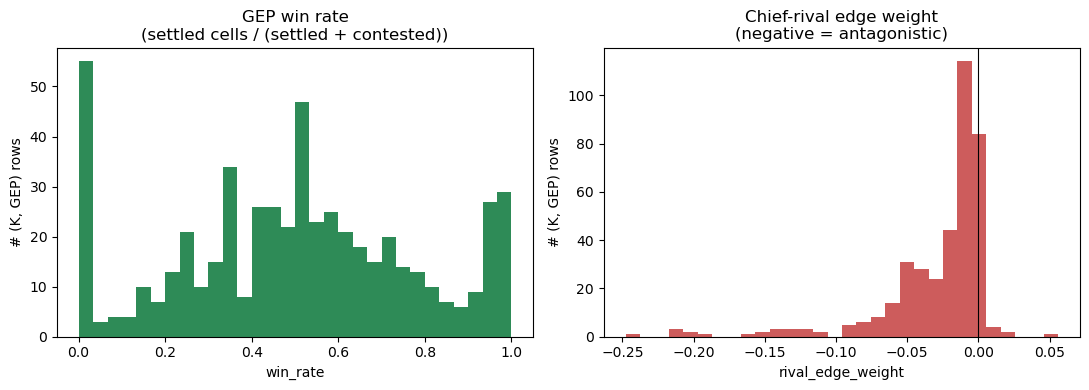

46.9% of rows have a chief rival that shares the same NB2 label as the GEP itself (expected when a label spans multiple GEPs at one K, e.g. a family label — otherwise a sign two GEPs assigned the same identity are competing for the same cells).

Lowest win_rate (K, GEP) rows (most 'never settles') with ≥50 dominant cells:
 K gep           label  n_dominant_cells  win_rate chief_rival_label  rival_edge_weight
30  12 Ambiguous/Mixed               243  0.034091   Ambiguous/Mixed          -0.011919
34  15 Ambiguous/Mixed               384  0.037433         DC_family          -0.023825
29  11 Ambiguous/Mixed               731  0.057143   Ambiguous/Mixed          -0.009913
33  20       DC_family                53  0.081081   Ambiguous/Mixed          -0.011500
24   9 Ambiguous/Mixed                64  0.096774            DC_pDC          -0.042812
33  15 Ambiguous/Mixed               172  0.098901   Ambiguous/Mixed          -0.012465
35   8 Ambiguous/Mixed                90  0.128205   Ambiguo

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(profile['win_rate'].dropna(), bins=30, color='seagreen')
axes[0].set(title='GEP win rate\n(settled cells / (settled + contested))',
            xlabel='win_rate', ylabel='# (K, GEP) rows')

axes[1].hist(profile['rival_edge_weight'].dropna(), bins=30, color='indianred')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set(title='Chief-rival edge weight\n(negative = antagonistic)',
            xlabel='rival_edge_weight', ylabel='# (K, GEP) rows')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'gep_negotiation_profile.png'), dpi=150, bbox_inches='tight')
plt.show()

rival_known = profile.dropna(subset=['chief_rival_label', 'label'])
same_label_rival = (rival_known['chief_rival_label'] == rival_known['label']).mean()
print(f"{same_label_rival:.1%} of rows have a chief rival that shares the same NB2 label as the "
      "GEP itself (expected when a label spans multiple GEPs at one K, e.g. a family label — "
      "otherwise a sign two GEPs assigned the same identity are competing for the same cells).")

print("\nLowest win_rate (K, GEP) rows (most 'never settles') with ≥50 dominant cells:")
print(profile[profile['n_dominant_cells'] >= 50]
      .nsmallest(10, 'win_rate')[['K', 'gep', 'label', 'n_dominant_cells', 'win_rate',
                                   'chief_rival_label', 'rival_edge_weight']]
      .to_string(index=False))

### 13. Visualization — UMAP colored by GPCI / conflict / state

Uses `adata.obsm['X_umap']`, already computed — no need to rebuild it. `REPRESENTATIVE_K` (1) picks which K's states are shown; change it and re-run this cell to inspect a different resolution.

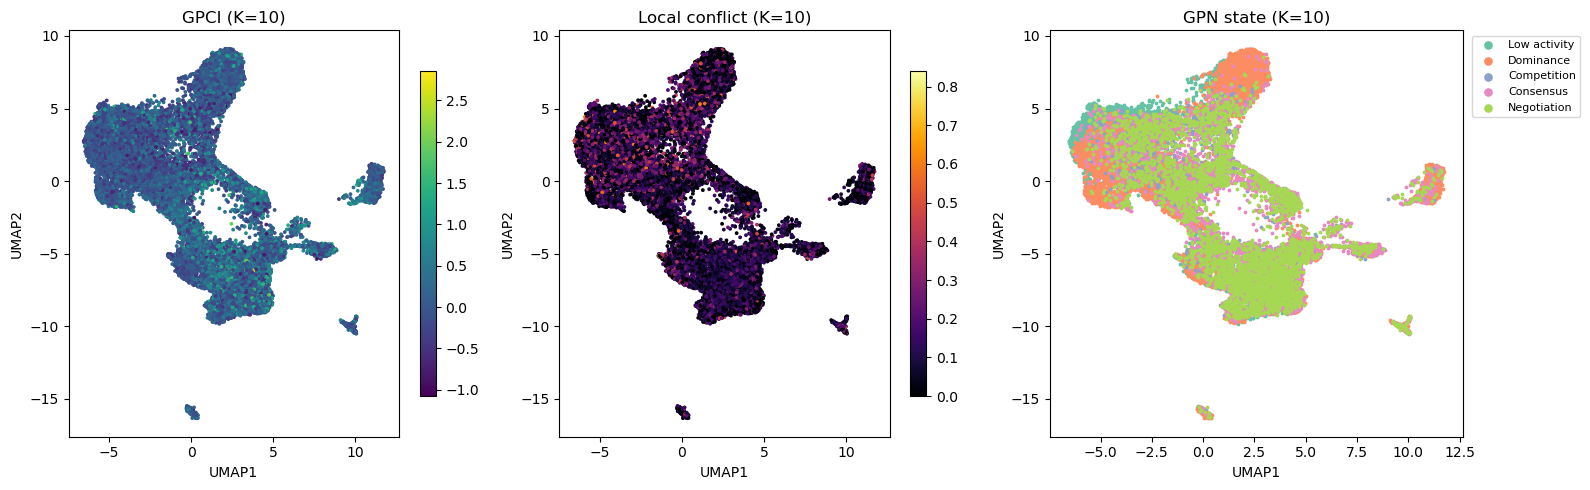

In [18]:
umap_df = pd.DataFrame(adata.obsm['X_umap'], columns=['UMAP1', 'UMAP2'], index=cell_names)

viz = gpn_states[gpn_states['K'] == REPRESENTATIVE_K].set_index('cell').join(umap_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sc0 = axes[0].scatter(viz['UMAP1'], viz['UMAP2'], c=viz['GPCI'], cmap='viridis', s=3)
axes[0].set(title=f'GPCI (K={REPRESENTATIVE_K})', xlabel='UMAP1', ylabel='UMAP2')
plt.colorbar(sc0, ax=axes[0], shrink=0.8)

sc1 = axes[1].scatter(viz['UMAP1'], viz['UMAP2'], c=viz['conflict'], cmap='inferno', s=3)
axes[1].set(title=f'Local conflict (K={REPRESENTATIVE_K})', xlabel='UMAP1', ylabel='UMAP2')
plt.colorbar(sc1, ax=axes[1], shrink=0.8)

state_colors = dict(zip(STATE_ORDER, sns.color_palette('Set2', n_colors=len(STATE_ORDER))))
for state, color in state_colors.items():
    sub = viz[viz['state'] == state]
    axes[2].scatter(sub['UMAP1'], sub['UMAP2'], s=3, color=color, label=state)
axes[2].set(title=f'GPN state (K={REPRESENTATIVE_K})', xlabel='UMAP1', ylabel='UMAP2')
axes[2].legend(markerscale=3, fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'umap_gpn_K{REPRESENTATIVE_K}.png'), dpi=150, bbox_inches='tight')
plt.show()

### 14. Save master outputs + summary

In [19]:
master_path = os.path.join(OUT_DIR, 'gpn_states.tsv')
gpn_states.to_csv(master_path, sep='\t', index=False)

print("GPN analysis complete.\n")
print(f"K values analyzed: {k_values}")
print(f"Total (cell, K) rows: {len(gpn_states)}")
print("\nOverall state distribution:")
print(gpn_states['state'].value_counts(normalize=True).round(3).to_string())
print(f"\nGEP negotiation profile: {len(profile)} (K, GEP) rows, "
      f"win_rate resolved for {profile['win_rate'].notna().sum()}, "
      f"chief_rival resolved for {profile['chief_rival'].notna().sum()}")
print(f"\nOutputs written to {OUT_DIR}/:")
for f in sorted(os.listdir(OUT_DIR)):
    print(f"  {f}")

GPN analysis complete.

K values analyzed: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
Total (cell, K) rows: 872652

Overall state distribution:
state
Dominance       0.338
Negotiation     0.208
Low activity    0.200
Consensus       0.171
Competition     0.083

GEP negotiation profile: 553 (K, GEP) rows, win_rate resolved for 542, chief_rival resolved for 386

Outputs written to hnc_combined5000hvg_clanp_results/gpn_results_per_gep/:
  comparison_C_per_K_spearman.csv
  dominance_share_by_K.png
  dominance_share_frac_above_cutoff_by_K.csv
  dominance_share_frac_above_cutoff_by_K.png
  gep_negotiation_profile.csv
  gep_negotiation_profile.png
  gep_rivalry_K10.csv
  gep_rivalry_K11.csv
  gep_rivalry_K12.csv
  gep_rivalry_K13.csv
  gep_rivalry_K14.csv
  gep_rivalry_K15.csv
  gep_rivalry_K16.csv
  gep_rivalry_K17.csv
  gep_rivalry_K18.csv
  gep_rivalry_K19.csv
  gep_rivalry_K20.csv
  gep_rivalry_K21.csv
  gep

### 15. Overall regulatory state distribution

8 classifies every (cell, K) row into one of five states and 14 prints the pooled distribution as text. Same numbers, as a single 100%-stacked bar.

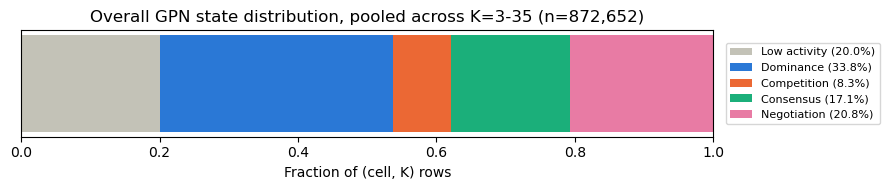

In [20]:
state_dist = gpn_states['state'].value_counts(normalize=True).reindex(STATE_ORDER)
state_colors_pooled = {'Low activity': '#c3c2b7', 'Dominance': '#2a78d6', 'Competition': '#eb6834',
                        'Consensus': '#1baf7a', 'Negotiation': '#e87ba4'}

fig, ax = plt.subplots(figsize=(9, 2))
left = 0
for state in STATE_ORDER:
    v = state_dist[state]
    ax.barh(0, v, left=left, color=state_colors_pooled[state], label=f"{state} ({v:.1%})")
    left += v
ax.set_yticks([])
ax.set_xlim(0, 1)
ax.set_xlabel('Fraction of (cell, K) rows')
ax.set_title(f'Overall GPN state distribution, pooled across K={min(k_values)}-{max(k_values)} '
             f'(n={len(gpn_states):,})')
ax.legend(bbox_to_anchor=(1.01, 0.5), loc='center left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "overall_state_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()